## Audio Classification EDA 

In [1]:
!pip install librosa


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
!dir

 Volume in drive D has no label.
 Volume Serial Number is 715E-F460

 Directory of D:\Project\Audio Classification

07/06/2026  12:42    <DIR>          .
01/06/2026  15:53    <DIR>          ..
07/06/2026  12:42    <DIR>          .ipynb_checkpoints
07/06/2026  12:39           401,942 Audio_Classification.ipynb
07/06/2026  12:17    <DIR>          saved_models
06/06/2026  17:44    <DIR>          UrbanSound8K
01/06/2026  16:45     6,023,741,708 UrbanSound8K.tar.gz
               2 File(s)  6,024,143,650 bytes
               5 Dir(s)  111,503,265,792 bytes free


In [4]:
filename = 'UrbanSound8K/UrbanSound8K/Chirping.wav'

In [5]:
import IPython.display as ipd
import librosa
import librosa.display

C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


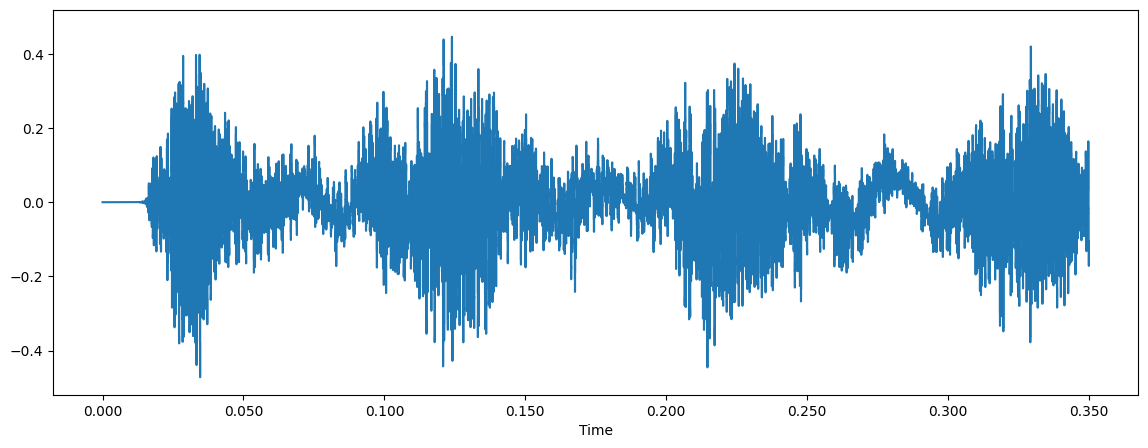

In [6]:
plt.figure(figsize = (14,5))
data,sample_rate =librosa.load(filename)
librosa.display.waveshow(data,sr= sample_rate)
ipd.Audio(filename)



In [7]:
import librosa
print(librosa.__version__)

0.11.0


In [8]:
sample_rate

22050

In [9]:
from scipy.io import wavfile as wav
wave_sample_rate, wave_audio = wav.read(filename)

In [10]:
wave_sample_rate

44100

In [11]:
wave_audio

array([[    0,     0],
       [    0,     0],
       [    0,     0],
       ...,
       [-7263, -3249],
       [-5536, -4567],
       [-3393, -5615]], shape=(15435, 2), dtype=int16)

In [12]:
data

array([ 3.7252903e-08, -7.4505806e-09,  7.4505806e-09, ...,
       -1.1671661e-01, -1.7172906e-01, -1.0471621e-01],
      shape=(7718,), dtype=float32)

In [13]:
import pandas as pd
metadata = pd.read_csv('UrbanSound8K/UrbanSound8K/metadata/UrbanSound8K.csv')
metadata.head(10)

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.000000,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.500000,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.500000,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.000000,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.500000,72.500000,1,5,2,children_playing
5,100263-2-0-143.wav,100263,71.500000,75.500000,1,5,2,children_playing
6,100263-2-0-161.wav,100263,80.500000,84.500000,1,5,2,children_playing
7,100263-2-0-3.wav,100263,1.500000,5.500000,1,5,2,children_playing
8,100263-2-0-36.wav,100263,18.000000,22.000000,1,5,2,children_playing
9,100648-1-0-0.wav,100648,4.823402,5.471927,2,10,1,car_horn


In [14]:
### Check whether the data is imbalanced 
metadata['class'].value_counts()

class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
engine_idling       1000
jackhammer          1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64

## Audio Classification Data Preprocessing


In [15]:
### Let's read a sample audio using librosa
import librosa
audio_file_path='UrbanSound8K/UrbanSound8K/6988-5-0-0.wav'
librosa_audio_data,librosa_sample_rate=librosa.load(audio_file_path)

In [16]:
print(librosa_audio_data)

[-7.4505806e-09  0.0000000e+00 -5.1222742e-09 ...  2.9722646e-01
  2.8743079e-01  3.1431502e-01]


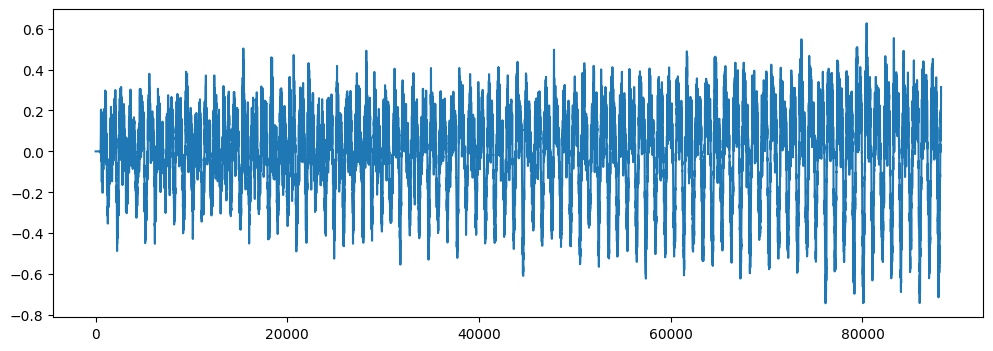

In [17]:
### Lets plot the librosa audio data
import matplotlib.pyplot as plt
# Original audio with 1 channel 
plt.figure(figsize=(12, 4))
plt.plot(librosa_audio_data)

In [18]:
### Lets read with scipy
from scipy.io import wavfile as wav
wave_sample_rate, wave_audio = wav.read(audio_file_path) 

In [19]:
wave_audio

array([[    0,     0],
       [    0,     0],
       [    0,     0],
       ...,
       [11185,  8202],
       [11214,  8240],
       [11053,  8593]], shape=(176400, 2), dtype=int16)

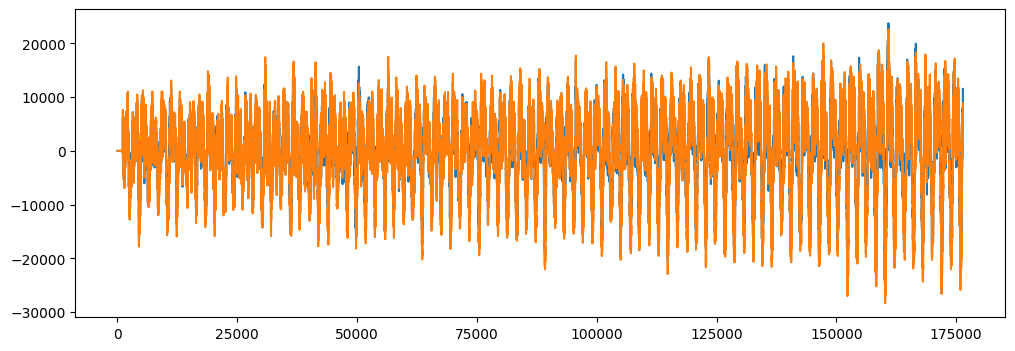

In [20]:
import matplotlib.pyplot as plt

# Original audio with 2 channels 
plt.figure(figsize=(12, 4))
plt.plot(wave_audio)

In [21]:
##Extract feature 
##Here we will be using Mel-Frequency Cepstral Coefficients(MFCC) from the audio samples. The MFCC summarises the frequency distribution across the window size, so it is possible to analyse both the frequency and time characteristics of the sound. These audio representations will allow us to identify features for classification.


In [22]:
mfccs = librosa.feature.mfcc(y=librosa_audio_data, sr=librosa_sample_rate, n_mfcc=40)
print(mfccs.shape)

(40, 173)


In [23]:
mfccs

array([[-2.65484802e+02, -1.51928619e+02, -1.43994125e+02, ...,
        -1.23618431e+02, -1.15628853e+02, -1.11803299e+02],
       [ 1.24438179e+02,  1.38863724e+02,  1.55250122e+02, ...,
         1.60569946e+02,  1.49438889e+02,  1.19188126e+02],
       [ 1.27878046e+00, -6.04183483e+00, -1.49665022e+01, ...,
        -2.58142452e+01, -2.25090256e+01, -5.38159943e+00],
       ...,
       [ 4.96517897e+00,  3.84755850e+00,  3.37911916e+00, ...,
         6.92507267e+00,  6.20935440e+00,  2.08514190e+00],
       [-4.47008133e+00, -2.24528861e+00,  9.53146517e-02, ...,
         6.62672281e+00,  3.68113494e+00,  5.03339767e+00],
       [-3.68895841e+00,  5.67847431e-01,  5.06569958e+00, ...,
         7.54012060e+00,  4.82909393e+00,  2.56265616e+00]],
      shape=(40, 173), dtype=float32)

In [24]:
#### Extracting MFCC's For every audio file
import pandas as pd
import os
import librosa

audio_dataset_path='UrbanSound8K/UrbanSound8K/audio/'
metadata=pd.read_csv('UrbanSound8K/UrbanSound8K/metadata/UrbanSound8K.csv')
metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [25]:
def features_extractor(file):
    audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast') 
    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
    
    return mfccs_scaled_features

In [26]:
import numpy as np
from tqdm import tqdm
### Now we iterate through every audio file and extract features 
### using Mel-Frequency Cepstral Coefficients
extracted_features=[]
for index_num,row in tqdm(metadata.iterrows()):
    file_name = os.path.join(os.path.abspath(audio_dataset_path),'fold'+str(row["fold"])+'/',str(row["slice_file_name"]))
    final_class_labels=row["class"]
    data=features_extractor(file_name)
    extracted_features.append([data,final_class_labels])

3554it [04:03, 15.85it/s]C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
8323it [09:05, 24.48it/s]C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
8327it [09:05, 27.61it/s]C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
8732it [09:30, 15.31it/s]


In [27]:
import sys
print(sys.version)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [28]:
### converting extracted_features to Pandas dataframe
extracted_features_df=pd.DataFrame(extracted_features,columns=['feature','class'])
extracted_features_df.head()

,feature,class
0,"[-217.35526, 70.22339, -130.38527, -53.282898,...",dog_bark
1,"[-424.09818, 109.34077, -52.919525, 60.86475, ...",children_playing
2,"[-458.79114, 121.38419, -46.520657, 52.00812, ...",children_playing
3,"[-413.89984, 101.66371, -35.42945, 53.036358, ...",children_playing
4,"[-446.60352, 113.68541, -52.402214, 60.30205, ...",children_playing


In [29]:
### Split the dataset into independent and dependent dataset
X=np.array(extracted_features_df['feature'].tolist())
y=np.array(extracted_features_df['class'].tolist())

In [30]:
X.shape

(8732, 40)

In [31]:
y

array(['dog_bark', 'children_playing', 'children_playing', ...,
       'car_horn', 'car_horn', 'car_horn'], shape=(8732,), dtype='<U16')

In [32]:

### Label Encoder
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

labelencoder = LabelEncoder()

y_encoded = labelencoder.fit_transform(y)

y = to_categorical(y_encoded)

In [33]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(8732, 10))

In [34]:
### Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [35]:
X_train

array([[-1.31104706e+02,  1.12505905e+02, -2.25746937e+01, ...,
         3.24665213e+00, -1.36902380e+00,  2.75575471e+00],
       [-1.36703424e+01,  9.10850830e+01, -7.79273319e+00, ...,
        -3.25305080e+00, -5.27745295e+00, -1.55697179e+00],
       [-4.98715439e+01,  2.65352994e-01, -2.05009365e+01, ...,
         2.85459447e+00, -1.60920465e+00,  3.52480578e+00],
       ...,
       [-4.27012360e+02,  9.26230469e+01,  3.12939811e+00, ...,
         7.42641211e-01,  7.33490884e-01,  7.11009026e-01],
       [-1.45754608e+02,  1.36265778e+02, -3.35155220e+01, ...,
         1.46811938e+00, -2.00917006e+00, -8.82181883e-01],
       [-4.21031342e+02,  2.10654541e+02,  3.49066091e+00, ...,
        -5.38886738e+00, -3.37136054e+00, -1.56651139e+00]],
      shape=(6985, 40), dtype=float32)

In [36]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(8732, 10))

In [37]:
X_train.shape

(6985, 40)

In [38]:
X_test.shape

(1747, 40)

In [39]:
y_train.shape

(6985, 10)

In [40]:
y_test.shape

(1747, 10)

## Model Creation

In [41]:
!pip install tensorflow


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten
from tensorflow.keras.optimizers import Adam
from sklearn import metrics

In [44]:
### No of classes
num_labels=y.shape[1]

In [45]:
model=Sequential()
###first layer
model.add(Dense(100,input_shape=(40,)))
model.add(Activation('relu'))
model.add(Dropout(0.5))
###second layer
model.add(Dense(200))
model.add(Activation('relu'))
model.add(Dropout(0.5))
###third layer
model.add(Dense(100))
model.add(Activation('relu'))
model.add(Dropout(0.5))

###final layer
model.add(Dense(num_labels))
model.add(Activation('softmax'))

C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 100)                 │           4,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 200)                 │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │          20,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,010 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 45,410 (177.38 KB)

 Trainable params: 45,410 (177.38 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='adam')

In [62]:
## Trianing my model
from tensorflow.keras.callbacks import ModelCheckpoint
from datetime import datetime
import os

os.makedirs("saved_models", exist_ok=True)

num_epochs = 100
num_batch_size = 32

checkpointer = ModelCheckpoint(
    filepath='saved_models/audio_classification.keras',
    verbose=1,
    save_best_only=True
)

start = datetime.now()

model.fit(
    X_train,
    y_train,
    batch_size=num_batch_size,
    epochs=num_epochs,
    validation_data=(X_test, y_test),
    callbacks=[checkpointer],
    verbose=1
)

duration = datetime.now() - start
print("Training completed in time:", duration)

Epoch 1/100
204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6780 - loss: 0.9830
Epoch 1: val_loss improved from None to 0.82968, saving model to saved_models/audio_classification.keras

Epoch 1: finished saving model to saved_models/audio_classification.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6807 - loss: 0.9870 - val_accuracy: 0.7390 - val_loss: 0.8297
Epoch 2/100
200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6829 - loss: 0.9694
Epoch 2: val_loss improved from 0.82968 to 0.80220, saving model to saved_models/audio_classification.keras

Epoch 2: finished saving model to saved_models/audio_classification.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6806 - loss: 0.9732 - val_accuracy: 0.7550 - val_loss: 0.8022
Epoch 3/100
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6966 - loss: 0.9304
Epoch 3: val_loss did not improve from 0.80220
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6850 - loss: 0.9663 - val_accuracy: 0.74

In [63]:
test_accuracy=model.evaluate(X_test,y_test,verbose=0)
print(test_accuracy[1])

0.7738981246948242


In [64]:
prediction_feature = X_test[0]

In [65]:
prediction_feature.shape

(40,)

In [66]:
X_test[1]

array([-466.17957   ,    1.0950246 ,  -34.01389   ,   35.339348  ,
        -14.881481  ,  -19.12843   ,   -0.581684  ,  -16.130579  ,
        -21.339073  ,    7.6736345 ,  -29.16449   ,  -18.950254  ,
         -2.9579992 ,   -8.162331  ,  -15.153101  ,   -6.6048055 ,
         -7.568598  ,    9.340646  ,   14.4331    ,   21.934181  ,
         20.861397  ,    1.3340123 ,  -19.228804  ,   -4.630231  ,
         -1.0564744 ,    3.215267  ,   -6.9842806 ,  -16.414577  ,
        -10.0286455 ,   13.009954  ,    0.53346086,  -23.84339   ,
        -15.267321  ,    9.245735  ,   10.367627  ,   -0.58320117,
         -1.2624053 ,   17.700016  ,   13.847463  ,   -5.1862826 ],
      dtype=float32)

In [67]:
import numpy as np

predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[5 3 4 ... 1 9 2]


## Testing Some Test Audio Data

In [68]:
filename="UrbanSound8K/UrbanSound8K/6988-5-0-0.wav"

audio, sample_rate = librosa.load(filename, res_type='kaiser_fast')

mfccs_features = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=40
)

mfccs_scaled_features = np.mean(mfccs_features.T, axis=0)

mfccs_scaled_features = mfccs_scaled_features.reshape(1, -1)

prediction = model.predict(mfccs_scaled_features)

predicted_label = np.argmax(prediction, axis=1)

print("Predicted Label Number:", predicted_label)

prediction_class = labelencoder.inverse_transform(predicted_label)

print("Predicted Class:", prediction_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Label Number: [5]
Predicted Class: ['engine_idling']


In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

In [70]:
# Predict probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded y_test back to class labels
y_true = np.argmax(y_test, axis=1)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [71]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")

Accuracy  : 77.39%
Precision : 79.95%
Recall    : 77.39%
F1-Score  : 77.90%
